# Laboratório 04 — ACO do Zero

**Missão:** construir, do zero, um algoritmo capaz de encontrar uma boa rota entre dois nós de uma rede, usando o conceito de ACO.

A rede tem 6 nós, origem no nó 0 e destino no nó 5. A matriz de custos foi fornecida pelo professor. O restante do programa (feromônio, formigas, construção de rota, avaliação, reforço, evaporação e repetição) foi escrito seguindo a mesma lógica trabalhada em aula, atendendo aos 12 requisitos do roteiro.


In [1]:
%matplotlib inline

## 1 e 2. Rede e matriz de feromônio

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

# matriz de feromônio: começa igual em todas as conexões que existem
feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

## Parâmetros mínimos pedidos no roteiro

In [3]:
NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

## 3. Vizinhos de um nó

Um nó só pode ir para outro se existir uma conexão direta (custo diferente de infinito).

In [4]:
def obter_vizinhos(no):

    vizinhos = []

    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos

## 4. Escolha do próximo nó

Junta feromônio e custo (1/custo) para decidir, de forma probabilística, para onde a formiga vai.

In [5]:
def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

    # 5. impede visitar de novo um nó que já está na rota
    candidatos = [no for no in vizinhos if no not in visitados]

    if not candidatos:
        return None

    atratividades = []
    for proximo in candidatos:
        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]
        atratividades.append((fer ** ALPHA) * (1 / custo) ** BETA)

    soma = sum(atratividades)
    probabilidades = [valor / soma for valor in atratividades]

    return random.choices(candidatos, weights=probabilidades, k=1)[0]

## 4 (continuação). Formiga constrói uma rota completa

In [6]:
def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        proximo = escolher_proximo(atual, rota)

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota

## 6. Custo de uma rota

In [7]:
def calcular_custo(rota):

    total = 0
    for i in range(len(rota) - 1):
        total += CUSTOS[rota[i]][rota[i + 1]]

    return total

## 7. Reforço das melhores rotas (depósito de feromônio)

In [8]:
def depositar_feromonio(rota, custo):

    deposito = Q / custo

    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        feromonio[origem][destino] += deposito

## 8. Evaporação

In [9]:
def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)
    feromonio[CUSTOS == np.inf] = 0

## 9, 10, 11 e 12. Colônia completa: repete por várias iterações, guarda a melhor rota, o melhor custo e a evolução do custo para o gráfico

In [10]:
melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):

    rotas_da_iteracao = []

    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()

        if rota is not None:
            custo = calcular_custo(rota)
            rotas_da_iteracao.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas_da_iteracao:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

print("========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


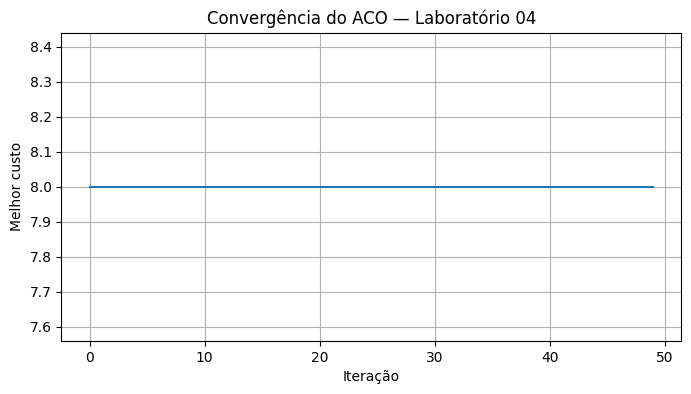

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO — Laboratório 04")
plt.grid()
plt.show()

## Explorando outros parâmetros

O roteiro pede para alterar `NUM_FORMIGAS`, `NUM_ITERACOES`, `ALPHA`, `BETA` e `TAXA_EVAPORACAO` e observar o comportamento. Testamos uma configuração bem diferente da original, como exemplo.

Nova configuração -> ALPHA=3.0, BETA=1.0, TAXA_EVAPORACAO=0.2, NUM_FORMIGAS=10, NUM_ITERACOES=30
Melhor rota encontrada: [0, 1, 2, 4, 5]
Melhor custo: 8.0


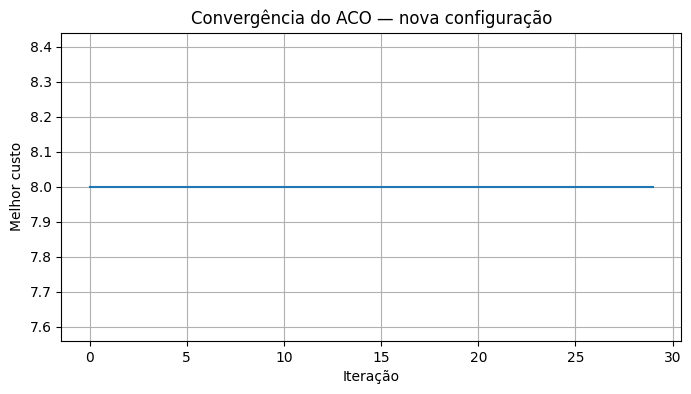

In [12]:
# nova configuração de teste
NUM_FORMIGAS = 10
NUM_ITERACOES = 30
ALPHA = 3.0
BETA = 1.0
TAXA_EVAPORACAO = 0.2

feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):

    rotas_da_iteracao = []

    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()

        if rota is not None:
            custo = calcular_custo(rota)
            rotas_da_iteracao.append((rota, custo))

            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas_da_iteracao:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

print("Nova configuração -> ALPHA=3.0, BETA=1.0, TAXA_EVAPORACAO=0.2, NUM_FORMIGAS=10, NUM_ITERACOES=30")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)

plt.figure(figsize=(8, 4))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO — nova configuração")
plt.grid()
plt.show()